## Notebook to analyse prediction performance of NN

In [52]:
# Define dataset, mode, NN model
dataset = "10000_2025-06-10_23-11-15"
powerspectrum_mode = "ll"
timestamp = '2025-08-27_20-13-31' #define model
processing_vector = "1000000_2025-06-11_05-16-31" #processing vector connected to model
namepredictedfile = "PredictedData_ll_3670_2025-09-08_11-52-27.json"


In [53]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.activations import gelu
from tensorflow.keras.losses import MeanSquaredError
import tensorflow_addons as tfa
import optuna
from tensorflow.keras.layers import LeakyReLU, ELU

# Für spezielle Aktivierungen wie Swish, GELU
try:
    from tensorflow.keras.activations import swish, gelu
except ImportError:
    # Alternative falls alte TensorFlow-Version
    def swish(x): return x * tf.nn.sigmoid(x)
    def gelu(x): return 0.5 * x * (1.0 + tf.tanh(tf.sqrt(2.0 / tf.constant(np.pi)) * (x + 0.044715 * tf.pow(x, 3))))

# Für AdamW und RAdam Optimizer:
try:
    from tensorflow_addons.optimizers import AdamW, RectifiedAdam
except ImportError:
    # Falls nicht installiert:
    # pip install tensorflow-addons
    print("Installiere tensorflow-addons mit: pip install tensorflow-addons")

In [54]:
#%pip install tensorflow
#%pip install pyDOE
#%pip install pandas
#%pip install seaborn
#%pip install tensorflow-addons
#%pip install filelock
#%pip install pyccl

In [55]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using cpu device 



## Read in generated Targets

In [56]:
np.random.seed(9721)
tf.random.set_seed(9721)

In [ ]:
# 1. Speicherort und Dateiname

data_dir = "../Data/"
data_fn = f"{data_dir}GeneratedData_{dataset}.json"

# 2. Relevante Keys für Galaxy-Matter

target_keys = [f'Pk_{powerspectrum_mode}_1h', f'Pk_{powerspectrum_mode}_2h', f'Pk_{powerspectrum_mode}']


# 3. Daten einlesen und filtern

clean_samples = []
kept_indices = []
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)
    for i, sample in enumerate(data_samples):
        if all(np.all(np.array(sample[key]) >= 0) for key in target_keys):
            clean_samples.append(sample)
            kept_indices.append(i)

print(f"Anzahl der verbleibenden (bereinigten) Samples: {len(clean_samples)}")


# Create numpy arrays for each of the Pk_* columns
targets_array = {
    key: np.array([sample[key] for sample in clean_samples])
    for key in target_keys
}


# Logarithmic transformation of the data
def log_transform(targets_array):
    return {key: np.log(data) for key, data in targets_array.items()}

#epsilon = 1e-8
#for key in targets_array:
    #targets_array[key] = np.where(targets_array[key] <= 0, epsilon, targets_array[key])

# Calculate logarithms of the data
log_transformed_data = log_transform(targets_array)

# Nach clean_samples erstellen
num_samples = len(clean_samples)
indices = np.arange(num_samples)
N_total = len(clean_samples)

N_test = N_total

print(f"Test: {num_samples}")

# 8. Hilfsfunktion zum Splitten
def split_data(array_dict, split_indices):
    return np.array([data[split_indices] for data in array_dict.values()])

# 9. Targets und Modes für Splits
testing_targets = {
    'modes': split_data(targets_array, indices),
    'targets': split_data(log_transformed_data, indices)
}

Anzahl der verbleibenden (bereinigten) Samples: 3670
Test: 3670


In [58]:
print('number of test targets:', len(testing_targets['modes'][:][0]), '. Should be', N_test)

number of test targets: 3670 . Should be 3670


In [59]:
N_modes=len(testing_targets['modes'])
print(f"Shape of testing targets: {testing_targets['targets'].shape}. Should be ({N_modes}, {N_test}, 50)")

Shape of testing targets: (3, 3670, 50). Should be (3, 3670, 50)


## Read in related features

In [60]:
# Parameterdatei einlesen
para_fn = f"{data_dir}Parameter_{dataset}.json"

with open(para_fn, "r") as json_file:
    all_parameter_samples = json.load(json_file)

# Parameter entsprechend kept_indices filtern (kept_indices kommt vom Target-Filter)
filtered_parameter_samples = [all_parameter_samples[i] for i in kept_indices]

# Keys für Parameter
feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

# Gefilterte Parameter in NumPy-Arrays umwandeln
feature_array = {
    key: np.array([sample[key] for sample in filtered_parameter_samples])
    for key in feature_keys
}

# Splitten mit denselben Indizes wie bei Targets
testing_features = np.array([feature_array[key][indices] for key in feature_keys]).T

In [61]:
log_indices = [7, 8]  # Ersetze mit deinen echten Indizes

testing_features[:, log_indices] = np.log10(testing_features[:, log_indices])

print("input min/max:", testing_features.min(), testing_features.max())

input min/max: 0.01009269043771584 16.999995314217603


In [62]:
print('number of test features:', len(testing_features), '. Should be', N_test)

number of test features: 3670 . Should be 3670


## Renaming

In [63]:
# features
test_targets=testing_targets['targets']

## Rescaling
We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.


In [64]:
# --- Preprocessing & Postprocessing Functions ---
def preprocessing(targets, processing_vectors):
    return (targets - processing_vectors['mean']) / processing_vectors['sigma']

def postprocessing(targets, processing_vectors):
    return targets * processing_vectors['sigma'] + processing_vectors['mean']


# --- Lade die gespeicherten Rescaling-Vektoren ---
processing_in = f"../Data/Rescaling/Processing_vectors_data_{processing_vector}_{powerspectrum_mode}.json"

with open(processing_in, "r") as json_file:
    loaded_vectors = json.load(json_file)

# Umwandeln von Listen zurück in numpy-Arrays
target_processing_vectors = {
    key: np.array(value) for key, value in loaded_vectors.items()
}

# --- Anwenden auf die Daten ---
test_targets_rescaled  = preprocessing(test_targets, target_processing_vectors)

# --- Check Shapes ---
print("Test Rescaled Shape:", test_targets_rescaled.shape)

Test Rescaled Shape: (3, 3670, 50)


In [65]:
# --- Preprocessing & Postprocessing ---
def preprocessing(features, processing_vectors):
    return (features - processing_vectors['mean']) / processing_vectors['sigma']

def postprocessing(features, processing_vectors):
    return features * processing_vectors['sigma'] + processing_vectors['mean']


# --- Lade gespeicherte Rescaling-Vektoren ---
processing_in = f"../Data/Rescaling/Processing_vectors_parameter_{processing_vector}_{powerspectrum_mode}.json"

with open(processing_in, "r") as json_file:
    loaded_vectors = json.load(json_file)

# Umwandeln zurück in numpy Arrays
feature_processing_vectors = {key: np.array(val) for key, val in loaded_vectors.items()}


# --- Anwenden auf die Daten ---
test_features_rescaled  = preprocessing(testing_features, feature_processing_vectors)


# --- Check Shapes ---
print("Test Rescaled Shape:", test_features_rescaled.shape)


Test Rescaled Shape: (3670, 10)


In [66]:
#restructuring of the arrays
test_targets_rescaled = np.transpose(test_targets_rescaled, (1, 0, 2))


In [67]:
#load

model = keras.models.load_model(
    f'../NN_builds/NN_{timestamp}.keras',
    compile=False
)
model.compile(optimizer=RectifiedAdam(), loss='mse')

In [68]:
#predicted data
emulated_testing = np.array(model.predict(test_features_rescaled, batch_size=N_total))

pred_targets= emulated_testing.reshape(N_test, 3, 50).transpose(1, 0, 2)
postprocessed_pred_targets= postprocessing(pred_targets, target_processing_vectors)


1/1 [==============================] - 0s 207ms/step


In [69]:
# Calculation of the difference
diff_1h = np.abs(postprocessed_pred_targets[0, :, :]/ test_targets[0,:,:] - 1)
diff_2h = np.abs(postprocessed_pred_targets[1, :, :] / test_targets[1,:,:] - 1)
diff_total = np.abs(postprocessed_pred_targets[2, :, :] / test_targets[2,:,:] - 1)

# Compute percentiles
percentiles_1h = np.zeros((4, diff_1h.shape[1]))
percentiles_2h = np.zeros((4, diff_2h.shape[1]))
percentiles_total = np.zeros((4, diff_total.shape[1]))

percentiles_1h[0] = np.percentile(diff_1h, 68, axis=0)
percentiles_1h[1] = np.percentile(diff_1h, 95, axis=0)
percentiles_1h[2] = np.percentile(diff_1h, 99, axis=0)
percentiles_1h[3] = np.percentile(diff_1h, 99.9, axis=0)

percentiles_2h[0] = np.percentile(diff_2h, 68, axis=0)
percentiles_2h[1] = np.percentile(diff_2h, 95, axis=0)
percentiles_2h[2] = np.percentile(diff_2h, 99, axis=0)
percentiles_2h[3] = np.percentile(diff_2h, 99.9, axis=0)

percentiles_total[0] = np.percentile(diff_total, 68, axis=0)
percentiles_total[1] = np.percentile(diff_total, 95, axis=0)
percentiles_total[2] = np.percentile(diff_total, 99, axis=0)
percentiles_total[3] = np.percentile(diff_total, 99.9, axis=0)

# Indices, bei denen die Differenz den 99. Perzentil überschreitet
indices_99 = np.argwhere(diff_1h >= percentiles_1h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_2h >= percentiles_2h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_total >= percentiles_total[None, 2])[:, 0]

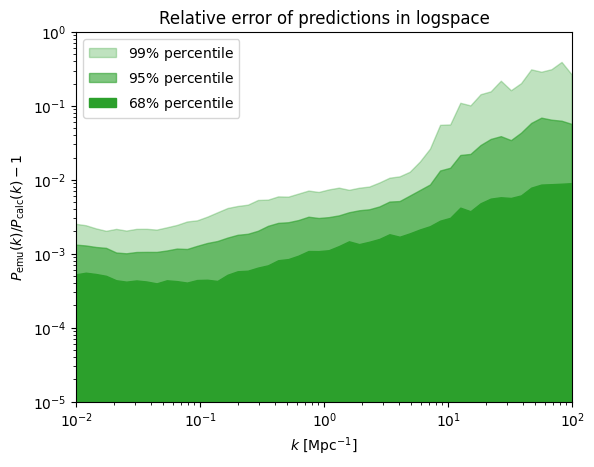

In [70]:
# do plot
fig, ax=plt.subplots()
ks = np.geomspace(1e-2, 1e2)
#ax.fill_between(ks, 0, percentiles_1h[2,:], color = 'C0', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_1h[1,:], color = 'C0', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_1h[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_2h[2,:], color = 'C1', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_2h[1,:], color = 'C1', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_2h[0,:], color = 'C1', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_total[3,:], color = 'C2', label = r'99.9\% percentile', alpha=0.1)
ax.fill_between(ks, 0, percentiles_total[2,:], color = 'C2', label = r'$99\%$ percentile', alpha=0.3)
ax.fill_between(ks, 0, percentiles_total[1,:], color = 'C2', label = r'$95\%$ percentile', alpha = 0.6)
ax.fill_between(ks, 0, percentiles_total[0,:], color = 'C2', label = r'$68\%$ percentile', alpha = 1)


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-5, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{calc}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of predictions in logspace')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()
#plt.savefig(f'../Plots/FinalExamples/relErrorTest.png', dpi=600)

In [71]:
# Calculation of the difference
diff_1h = np.abs(np.exp(postprocessed_pred_targets[0, :, :])/ np.exp(test_targets[0,:,:]) - 1)
diff_2h = np.abs(np.exp(postprocessed_pred_targets[1, :, :]) / np.exp(test_targets[1,:,:]) - 1)
diff_total = np.abs(np.exp(postprocessed_pred_targets[2, :, :]) / np.exp(test_targets[2,:,:]) - 1)

# Compute percentiles
percentiles_1h = np.zeros((4, diff_1h.shape[1]))
percentiles_2h = np.zeros((4, diff_2h.shape[1]))
percentiles_total = np.zeros((4, diff_total.shape[1]))

percentiles_1h[0] = np.percentile(diff_1h, 68, axis=0)
percentiles_1h[1] = np.percentile(diff_1h, 95, axis=0)
percentiles_1h[2] = np.percentile(diff_1h, 99, axis=0)
percentiles_1h[3] = np.percentile(diff_1h, 99.9, axis=0)

percentiles_2h[0] = np.percentile(diff_2h, 68, axis=0)
percentiles_2h[1] = np.percentile(diff_2h, 95, axis=0)
percentiles_2h[2] = np.percentile(diff_2h, 99, axis=0)
percentiles_2h[3] = np.percentile(diff_2h, 99.9, axis=0)

percentiles_total[0] = np.percentile(diff_total, 68, axis=0)
percentiles_total[1] = np.percentile(diff_total, 95, axis=0)
percentiles_total[2] = np.percentile(diff_total, 99, axis=0)
percentiles_total[3] = np.percentile(diff_total, 99.9, axis=0)

# Indices, bei denen die Differenz den 99. Perzentil überschreitet
indices_99 = np.argwhere(diff_1h >= percentiles_1h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_2h >= percentiles_2h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_total >= percentiles_total[None, 2])[:, 0]

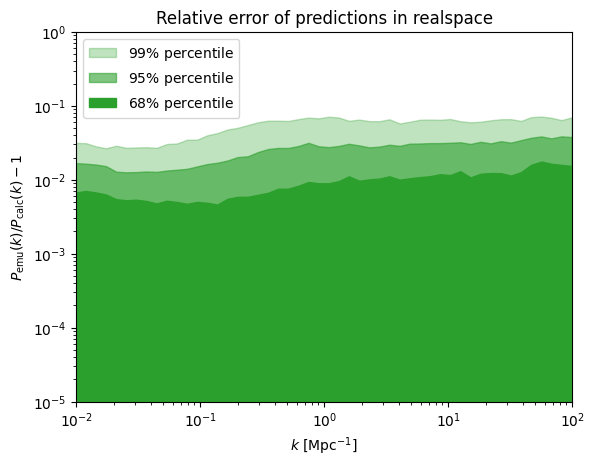

In [72]:
# do plot
fig, ax=plt.subplots()
ks = np.geomspace(1e-2, 1e2)
#ax.fill_between(ks, 0, percentiles_1h[2,:], color = 'C0', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_1h[1,:], color = 'C0', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_1h[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_2h[2,:], color = 'C1', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_2h[1,:], color = 'C1', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_2h[0,:], color = 'C1', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_total[3,:], color = 'C2', label = r'99.9\% percentile', alpha=0.1)
ax.fill_between(ks, 0, percentiles_total[2,:], color = 'C2', label = r'$99\%$ percentile', alpha=0.3)
ax.fill_between(ks, 0, percentiles_total[1,:], color = 'C2', label = r'$95\%$ percentile', alpha = 0.6)
ax.fill_between(ks, 0, percentiles_total[0,:], color = 'C2', label = r'$68\%$ percentile', alpha = 1)


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-5, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{calc}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of predictions in realspace')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()
#plt.savefig(f'../Plots/FinalExamples/relErrorTest.png', dpi=600)

In [73]:
are_equal = np.array_equal(postprocessed_pred_targets[2], test_targets[2])
print("Arrays sind identisch:", are_equal)

mae = np.mean(np.abs(postprocessed_pred_targets[2] - test_targets[2]))
print("Mittlerer absoluter Fehler (MAE):", mae)

correlation = np.corrcoef(postprocessed_pred_targets[2].flatten(), test_targets[2].flatten())[0, 1]
print("Korrelationskoeffizient:", correlation)

relative_diff = np.abs((postprocessed_pred_targets[2] - test_targets[2]) / postprocessed_pred_targets[2])
mean_relative_diff = np.mean(relative_diff) * 100
print(f"Mittlere relative Abweichung: {mean_relative_diff:.2f}%")

Arrays sind identisch: False
Mittlerer absoluter Fehler (MAE): 0.008699873682287149
Korrelationskoeffizient: 0.9999939028289899
Mittlere relative Abweichung: 1.19%


In [74]:
are_equal = np.array_equal(np.exp(postprocessed_pred_targets[2]), np.exp(test_targets[2]))
print("Arrays sind identisch:", are_equal)

mae = np.mean(np.abs(np.exp(postprocessed_pred_targets[2]) - np.exp(test_targets[2])))
print("Mittlerer absoluter Fehler (MAE):", mae)

correlation = np.corrcoef(np.exp(postprocessed_pred_targets[2]).flatten(), np.exp(test_targets[2]).flatten())[0, 1]
print("Korrelationskoeffizient:", correlation)

relative_diff = np.abs((np.exp(postprocessed_pred_targets[2]) - np.exp(test_targets[2])) / np.exp(postprocessed_pred_targets[2]))
mean_relative_diff = np.mean(relative_diff) * 100
print(f"Mittlere relative Abweichung: {mean_relative_diff:.2f}%")

Arrays sind identisch: False
Mittlerer absoluter Fehler (MAE): 1264.5855531920588
Korrelationskoeffizient: 0.9997079966489205
Mittlere relative Abweichung: 0.87%


In [75]:
calculatedfile = data_fn
predictedfile = f"{data_dir}{namepredictedfile}"

In [77]:
import json
import numpy as np

# Dateien laden
with open(predictedfile, "r") as f:
    predicted_data = json.load(f)

with open(calculatedfile, "r") as f:
    calculated_data = json.load(f)

# Anzahl der Samples (sollte gleich sein!)
N_total = min(len(predicted_data), len(calculated_data))
print(f"Vergleiche {N_total} Samples")

# Keys, die wir vergleichen wollen
keys = target_keys

errors = {k: [] for k in keys}

for i in range(N_total):
    pred = predicted_data[i]
    calc = calculated_data[i]
    
    for k in keys:
        p = np.array(pred[k])
        c = np.array(calc[k])
        
        # relativer Fehler pro k-Wert
        rel_err = np.abs((p - c) / c)
        errors[k].append(rel_err)

# Arrays zusammenbauen
for k in keys:
    errors[k] = np.vstack(errors[k])  # shape (N_total, 50)

# Jetzt können wir Statistiken ausgeben
for k in keys:
    mean_err = np.mean(errors[k])
    median_err = np.median(errors[k])
    max_err = np.max(errors[k])
    print(f"{k}: Mittel {mean_err:.4e}, Median {median_err:.4e}, Max {max_err:.4e}")


Vergleiche 3670 Samples
Pk_ll_1h: Mittel 5.8819e+03, Median 1.0166e+00, Max 3.3830e+07
Pk_ll_2h: Mittel 2.5728e+01, Median 6.5649e-01, Max 6.6489e+05
Pk_ll: Mittel 6.1911e+01, Median 9.9680e-01, Max 1.1068e+06


In [78]:
import os
import json
import numpy as np

# -----------------------------
# 1. Speicherort und Dateiname
# -----------------------------

# -----------------------------
# 2. Relevante Keys (nur ein Mode)
# -----------------------------
target_keys = [f'Pk_{powerspectrum_mode}_1h', 
               f'Pk_{powerspectrum_mode}_2h', 
               f'Pk_{powerspectrum_mode}']

# -----------------------------
# 3. Daten einlesen
# -----------------------------
predicted_samples = []
kept_indices = []
with open(predictedfile, "r") as json_file:
    data_samples = json.load(json_file)
    for i, sample in enumerate(data_samples):
        # Falls du hier auch ein Filterkriterium möchtest wie bei calculated:
        if all(np.all(np.isfinite(sample[key])) for key in target_keys):
            predicted_samples.append(sample)
            kept_indices.append(i)

print(f"Anzahl eingelesener Predicted-Samples: {len(predicted_samples)}")

# -----------------------------
# 4. In NumPy-Arrays umwandeln
# -----------------------------
predicted_array = {
    key: np.array([sample[key] for sample in predicted_samples])
    for key in target_keys
}

# -----------------------------
# 5. Logarithmische Transformation
# -----------------------------
def log_transform(targets_array):
    return {key: np.log(data) for key, data in targets_array.items()}

log_predicted_data = log_transform(predicted_array)

# -----------------------------
# 6. Indizes und Split-Struktur
# -----------------------------
num_samples = len(predicted_samples)
indices = np.arange(num_samples)
N_total = num_samples

N_test = N_total  # falls du alles für Testing nutzen willst

print(f"Test-Samples: {num_samples}")

# -----------------------------
# 7. Hilfsfunktion zum Splitten
# -----------------------------
def split_data(array_dict, split_indices):
    return np.array([data[split_indices] for data in array_dict.values()])

# -----------------------------
# 8. Targets und Modes für Splits
# -----------------------------
testing_predicted = {
    'modes': split_data(predicted_array, indices),
    'targets': split_data(log_predicted_data, indices)
}

pred_targets=testing_predicted['modes']

Anzahl eingelesener Predicted-Samples: 3670
Test-Samples: 3670


In [79]:
# Calculation of the difference
diff_1h = np.abs(np.log(pred_targets[0, :, :])/ test_targets[0,:,:] - 1)
diff_2h = np.abs(np.log(pred_targets[1, :, :]) / test_targets[1,:,:] - 1)
diff_total = np.abs(np.log(pred_targets[2, :, :]) / test_targets[2,:,:] - 1)

# Compute percentiles
percentiles_1h = np.zeros((4, diff_1h.shape[1]))
percentiles_2h = np.zeros((4, diff_2h.shape[1]))
percentiles_total = np.zeros((4, diff_total.shape[1]))

percentiles_1h[0] = np.percentile(diff_1h, 68, axis=0)
percentiles_1h[1] = np.percentile(diff_1h, 95, axis=0)
percentiles_1h[2] = np.percentile(diff_1h, 99, axis=0)
percentiles_1h[3] = np.percentile(diff_1h, 99.9, axis=0)

percentiles_2h[0] = np.percentile(diff_2h, 68, axis=0)
percentiles_2h[1] = np.percentile(diff_2h, 95, axis=0)
percentiles_2h[2] = np.percentile(diff_2h, 99, axis=0)
percentiles_2h[3] = np.percentile(diff_2h, 99.9, axis=0)

percentiles_total[0] = np.percentile(diff_total, 68, axis=0)
percentiles_total[1] = np.percentile(diff_total, 95, axis=0)
percentiles_total[2] = np.percentile(diff_total, 99, axis=0)
percentiles_total[3] = np.percentile(diff_total, 99.9, axis=0)

# Indices, bei denen die Differenz den 99. Perzentil überschreitet
indices_99 = np.argwhere(diff_1h >= percentiles_1h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_2h >= percentiles_2h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_total >= percentiles_total[None, 2])[:, 0]

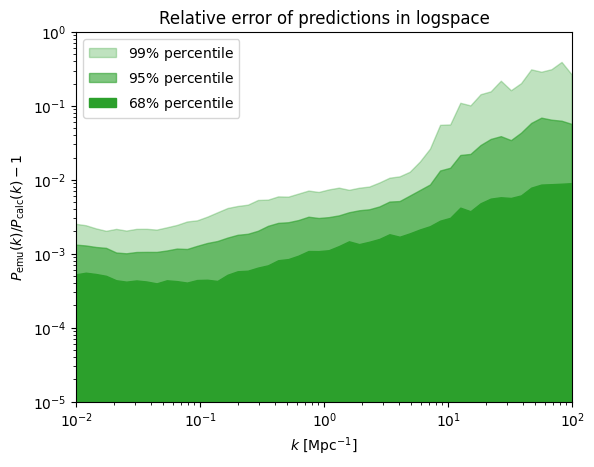

In [80]:
# do plot
fig, ax=plt.subplots()
ks = np.geomspace(1e-2, 1e2)
#ax.fill_between(ks, 0, percentiles_1h[2,:], color = 'C0', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_1h[1,:], color = 'C0', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_1h[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_2h[2,:], color = 'C1', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_2h[1,:], color = 'C1', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_2h[0,:], color = 'C1', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_total[3,:], color = 'C2', label = r'99.9\% percentile', alpha=0.1)
ax.fill_between(ks, 0, percentiles_total[2,:], color = 'C2', label = r'$99\%$ percentile', alpha=0.3)
ax.fill_between(ks, 0, percentiles_total[1,:], color = 'C2', label = r'$95\%$ percentile', alpha = 0.6)
ax.fill_between(ks, 0, percentiles_total[0,:], color = 'C2', label = r'$68\%$ percentile', alpha = 1)


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-5, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{calc}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of predictions in logspace')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()
#plt.savefig(f'../Plots/FinalExamples/relErrorTest.png', dpi=600)

In [81]:
# Calculation of the difference
diff_1h = np.abs(pred_targets[0, :, :]/ np.exp(test_targets[0,:,:]) - 1)
diff_2h = np.abs(pred_targets[1, :, :] / np.exp(test_targets[1,:,:]) - 1)
diff_total = np.abs(pred_targets[2, :, :] / np.exp(test_targets[2,:,:]) - 1)

# Compute percentiles
percentiles_1h = np.zeros((4, diff_1h.shape[1]))
percentiles_2h = np.zeros((4, diff_2h.shape[1]))
percentiles_total = np.zeros((4, diff_total.shape[1]))

percentiles_1h[0] = np.percentile(diff_1h, 68, axis=0)
percentiles_1h[1] = np.percentile(diff_1h, 95, axis=0)
percentiles_1h[2] = np.percentile(diff_1h, 99, axis=0)
percentiles_1h[3] = np.percentile(diff_1h, 99.9, axis=0)

percentiles_2h[0] = np.percentile(diff_2h, 68, axis=0)
percentiles_2h[1] = np.percentile(diff_2h, 95, axis=0)
percentiles_2h[2] = np.percentile(diff_2h, 99, axis=0)
percentiles_2h[3] = np.percentile(diff_2h, 99.9, axis=0)

percentiles_total[0] = np.percentile(diff_total, 68, axis=0)
percentiles_total[1] = np.percentile(diff_total, 95, axis=0)
percentiles_total[2] = np.percentile(diff_total, 99, axis=0)
percentiles_total[3] = np.percentile(diff_total, 99.9, axis=0)

# Indices, bei denen die Differenz den 99. Perzentil überschreitet
indices_99 = np.argwhere(diff_1h >= percentiles_1h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_2h >= percentiles_2h[None, 2])[:, 0]
indices_99 = np.argwhere(diff_total >= percentiles_total[None, 2])[:, 0]

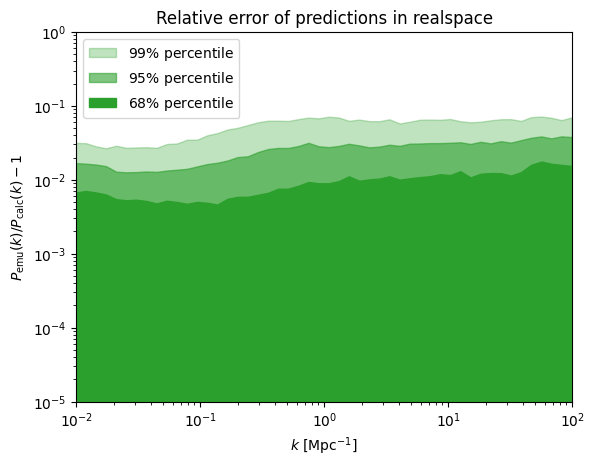

In [82]:
# do plot
fig, ax=plt.subplots()
ks = np.geomspace(1e-2, 1e2)
#ax.fill_between(ks, 0, percentiles_1h[2,:], color = 'C0', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_1h[1,:], color = 'C0', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_1h[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_2h[2,:], color = 'C1', label = r'99\% percentile', alpha=0.3)
#ax.fill_between(ks, 0, percentiles_2h[1,:], color = 'C1', label = r'95\% percentile', alpha = 0.6)
#ax.fill_between(ks, 0, percentiles_2h[0,:], color = 'C1', label = r'68\% percentile', alpha = 1)

#ax.fill_between(ks, 0, percentiles_total[3,:], color = 'C2', label = r'99.9\% percentile', alpha=0.1)
ax.fill_between(ks, 0, percentiles_total[2,:], color = 'C2', label = r'$99\%$ percentile', alpha=0.3)
ax.fill_between(ks, 0, percentiles_total[1,:], color = 'C2', label = r'$95\%$ percentile', alpha = 0.6)
ax.fill_between(ks, 0, percentiles_total[0,:], color = 'C2', label = r'$68\%$ percentile', alpha = 1)


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-5, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{calc}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of predictions in realspace')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()
#plt.savefig(f'../Plots/FinalExamples/relErrorTest.png', dpi=600)

In [83]:
are_equal = np.array_equal(pred_targets[2], np.exp(test_targets[2]))
print("Arrays sind identisch:", are_equal)

mae = np.mean(np.abs(pred_targets[2] - np.exp(test_targets[2])))
print("Mittlerer absoluter Fehler (MAE):", mae)

correlation = np.corrcoef(pred_targets[2].flatten(), np.exp(test_targets[2]).flatten())[0, 1]
print("Korrelationskoeffizient:", correlation)

relative_diff = np.abs((pred_targets[2] - np.exp(test_targets[2])) / pred_targets[2])
mean_relative_diff = np.mean(relative_diff) * 100
print(f"Mittlere relative Abweichung: {mean_relative_diff:.2f}%")

Arrays sind identisch: False
Mittlerer absoluter Fehler (MAE): 1264.5855531920588
Korrelationskoeffizient: 0.9997079966489205
Mittlere relative Abweichung: 0.87%
